In [104]:
import numpy as np
import pandas as pd

In [105]:
symptom_disease_df = pd.read_csv("synthetic_symptom_disease_dataset.csv")
symptom_disease_df



,label,text
0,Allergy,i have runny nose allergy for ten days
1,Anxiety,"for the last two days, i am dealing with restl..."
2,Bronchitis,persistent cough mucus
3,Migraine,one sided head pain
4,Allergy,i have itchy throat sneezing for ten days
...,...,...
94495,Fungal Infection,red patches fungal infection
94496,Sinusitis,blocked nose headache
94497,Malaria,i have fever chills sweating for two days
94498,Common Cold,i have mild cold and cough for three days


In [106]:
# i have to add one more column that tells about the length of each text 

def find_length(text):
    return len(str(text).split())

symptom_disease_df['length'] = symptom_disease_df['text'].apply(find_length)
symptom_disease_df['length'].describe()



count    94500.000000
mean         9.838741
std          7.143758
min          2.000000
25%          3.000000
50%          8.000000
75%         19.000000
max         24.000000
Name: length, dtype: float64

In [107]:
MAX_LEN = 60
MAX_WORDS = 10000


In [108]:
symptom_disease_df

,label,text,length
0,Allergy,i have runny nose allergy for ten days,8
1,Anxiety,"for the last two days, i am dealing with restl...",20
2,Bronchitis,persistent cough mucus,3
3,Migraine,one sided head pain,4
4,Allergy,i have itchy throat sneezing for ten days,8
...,...,...,...
94495,Fungal Infection,red patches fungal infection,4
94496,Sinusitis,blocked nose headache,3
94497,Malaria,i have fever chills sweating for two days,8
94498,Common Cold,i have mild cold and cough for three days,9


In [109]:
# clean the text using NLP text preprocessing 

# converting to lowercase 
symptom_disease_df['text'] = symptom_disease_df['text'].str.lower()

#remove punctuation 
import string 
exclude = string.punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('','',exclude))
symptom_disease_df['text'] = symptom_disease_df['text'].apply(remove_punctuation)

# removing spaces 
import re 
def remove_spaces(text):
    return re.sub(r"\s+"," ",text).strip()
symptom_disease_df['text'] = symptom_disease_df['text'].apply(remove_spaces)

symptom_disease_df


,label,text,length
0,Allergy,i have runny nose allergy for ten days,8
1,Anxiety,for the last two days i am dealing with restle...,20
2,Bronchitis,persistent cough mucus,3
3,Migraine,one sided head pain,4
4,Allergy,i have itchy throat sneezing for ten days,8
...,...,...,...
94495,Fungal Infection,red patches fungal infection,4
94496,Sinusitis,blocked nose headache,3
94497,Malaria,i have fever chills sweating for two days,8
94498,Common Cold,i have mild cold and cough for three days,9


In [110]:
# apply label encoding -> label encoding because it works on ordinal data and we have to convert into numbrs in orders 


from sklearn.preprocessing import LabelEncoder 

label_encoder = LabelEncoder()
symptom_disease_df['label id'] = label_encoder.fit_transform(symptom_disease_df['label'])
symptom_disease_df 

NUM_CLASSES = len(label_encoder.classes_)

In [111]:
# after converting to numbers , we have to split the data 


from sklearn.model_selection import train_test_split
X = symptom_disease_df['text']
Y = symptom_disease_df['label id']

X_train,X_test,Y_train,Y_test = train_test_split(
    X , Y , test_size = 0.2 , random_state= 42 ,stratify=Y
)


In [112]:
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)


(75600,) (18900,)
(75600,) (18900,)


In [113]:
# Tokenization using keras 

from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)
print(X_train_pad.shape)
print(X_test_pad.shape)
print(X_train_pad[0])


(75600, 60)
(18900, 60)
[  2   4 157  37  74   3  19   5   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0]


In [127]:
# Embedding

import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding , LSTM , Dense , Dropout , Bidirectional
from tensorflow.keras.callbacks import EarlyStopping 
from tensorflow.keras.layers import SpatialDropout1D


model = Sequential()

model.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128 ,
        input_length = MAX_LEN
    )
)



model.add(SpatialDropout1D(0.3))


# early stopping 
callback = EarlyStopping(
    monitor = 'val_loss',
    patience = 3 ,
    restore_best_weights = True
)
# Bidirectional layer 

model.add(Bidirectional(LSTM(128,return_sequences=True)))
# LSTM 

model.add(LSTM(64))

# Dropout 

model.add(Dropout(0.5))

# Dense layers 

model.add(Dense(NUM_CLASSES ,activation='softmax'))

from tensorflow.keras.utils import to_categorical

Y_train_oh = to_categorical(Y_train, num_classes=NUM_CLASSES)
Y_test_oh  = to_categorical(Y_test, num_classes=NUM_CLASSES)


# compiling the model 

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy", 
    metrics=["accuracy"]
)


# training the model 

history = model.fit(X_train_pad , Y_train_oh , epochs = 100 , validation_split=0.1 ,batch_size=32 , callbacks = [callback])
history 


Epoch 1/100


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2127/2127 ━━━━━━━━━━━━━━━━━━━━ 147s 67ms/step - accuracy: 0.2010 - loss: 2.5003 - val_accuracy: 0.7134 - val_loss: 0.7484
Epoch 2/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 278s 131ms/step - accuracy: 0.7398 - loss: 0.6753 - val_accuracy: 0.9005 - val_loss: 0.3134
Epoch 3/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 148s 70ms/step - accuracy: 0.8676 - loss: 0.4124 - val_accuracy: 0.9874 - val_loss: 0.0857
Epoch 4/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 150s 70ms/step - accuracy: 0.9097 - loss: 0.3030 - val_accuracy: 0.9880 - val_loss: 0.0550
Epoch 5/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 3772s 2s/step - accuracy: 0.9132 - loss: 0.3071 - val_accuracy: 0.9950 - val_loss: 0.0496
Epoch 6/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 119s 56ms/step - accuracy: 0.9316 - loss: 0.2487 - val_accuracy: 0.9101 - val_loss: 0.3422
Epoch 7/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 143s 67ms/step - accuracy: 0.8655 - loss: 0.4262 - val_accuracy: 0.9821 - val_loss: 0.0769
Epoch 8/100
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 186s 60ms/step - accuracy: 0.95

In [131]:
test_loss, test_accuracy = model.evaluate(X_test_pad, Y_test_oh)
print("Test Accuracy:", test_accuracy)


591/591 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9970 - loss: 0.0465
Test Accuracy: 0.9969841241836548


In [132]:
from sklearn.metrics import classification_report

Y_pred = model.predict(X_test_pad).argmax(axis=1)

print(
    classification_report(
        Y_test,
        Y_pred,
        target_names=label_encoder.classes_
    )
)


591/591 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step
                         precision    recall  f1-score   support

                Allergy       0.99      0.94      0.96       700
                 Anemia       0.95      1.00      0.97       700
                Anxiety       1.00      1.00      1.00       700
              Arthritis       1.00      1.00      1.00       700
                 Asthma       1.00      1.00      1.00       700
              Back Pain       1.00      1.00      1.00       700
             Bronchitis       0.99      1.00      0.99       700
               COVID-19       1.00      1.00      1.00       700
            Common Cold       1.00      0.99      0.99       700
         Conjunctivitis       1.00      1.00      1.00       700
                 Dengue       1.00      1.00      1.00       700
             Depression       1.00      1.00      1.00       700
               Diabetes       1.00      1.00      1.00       700
                    Flu       1.00      1.00  

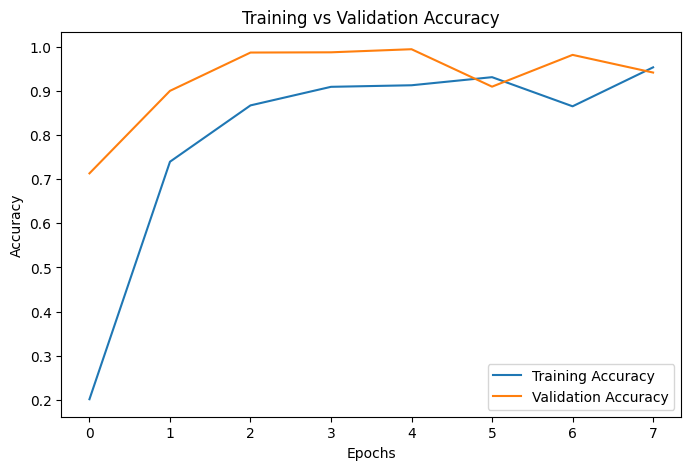

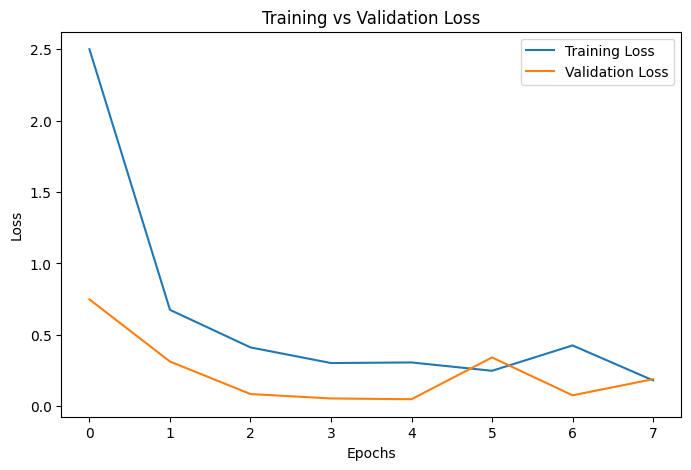

In [133]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


In [136]:
model.save("model/symptom_model1.h5") 
import pickle 
with open("model/tokenizer.pkl", "wb") as f: 
    pickle.dump(tokenizer, f) 
    
with open("model/label_encoder.pkl", "wb") as f: 
    pickle.dump(label_encoder, f)